In [1]:
import hopsworks

proj = hopsworks.login()
fs = proj.get_feature_store()

2025-08-22 12:11:43,515 INFO: Python Engine initialized.

Logged in to project, explore it here https://snurran.devnet.hops.works/p/120


In [2]:
fg =  fs.get_feature_group("wider_face_files", version=1)

In [3]:
df = fg.read()
df

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (0.19s) 


,file_path,file_timestamp,file_size_mb,num_bboxes,bboxes,label,ingested_at
0,/hopsfs/Jupyter/yolov8-face/data/WIDER_train/i...,2025-08-21 08:06:56+00:00,0.115531,2,"[[546, 253, 250, 331, 0, 0, 0, 0, 0, 0], [427,...",train,2025-08-21 09:59:36.537187+00:00
1,/hopsfs/Jupyter/yolov8-face/data/WIDER_train/i...,2025-08-21 08:03:27+00:00,0.091335,7,"[[300, 290, 41, 64, 1, 0, 0, 0, 0, 0], [405, 2...",train,2025-08-21 09:59:36.537187+00:00
2,/hopsfs/Jupyter/yolov8-face/data/WIDER_train/i...,2025-08-21 08:02:25+00:00,0.090383,11,"[[408, 225, 23, 28, 1, 0, 0, 0, 0, 0], [385, 2...",train,2025-08-21 09:59:36.537187+00:00
3,/hopsfs/Jupyter/yolov8-face/data/WIDER_val/ima...,2025-08-21 08:02:59+00:00,0.081689,2,"[[606, 42, 108, 160, 0, 0, 0, 0, 0, 0], [572, ...",val,2025-08-21 09:59:40.996966+00:00
4,/hopsfs/Jupyter/yolov8-face/data/WIDER_train/i...,2025-08-21 08:03:26+00:00,0.087067,13,"[[343, 231, 22, 28, 2, 0, 0, 0, 0, 0], [391, 2...",train,2025-08-21 09:59:36.537187+00:00
...,...,...,...,...,...,...,...
3076,/hopsfs/Jupyter/yolov8-face/data/WIDER_val/ima...,2025-08-21 08:02:16+00:00,0.052416,14,"[[955, 77, 26, 31, 1, 0, 0, 0, 0, 0], [866, 72...",val,2025-08-21 09:59:40.996966+00:00
3077,/hopsfs/Jupyter/yolov8-face/data/WIDER_train/i...,2025-08-21 08:05:40+00:00,0.125594,1,"[[277, 173, 233, 318, 0, 0, 0, 0, 0, 0]]",train,2025-08-21 09:59:36.537187+00:00
3078,/hopsfs/Jupyter/yolov8-face/data/WIDER_train/i...,2025-08-21 08:02:19+00:00,0.059752,3,"[[106, 148, 58, 94, 0, 0, 0, 0, 0, 0], [208, 1...",train,2025-08-21 09:59:36.537187+00:00
3079,/hopsfs/Jupyter/yolov8-face/data/WIDER_train/i...,2025-08-21 08:05:11+00:00,0.040192,2,"[[648, 44, 82, 150, 0, 0, 1, 0, 0, 0], [240, 1...",train,2025-08-21 09:59:36.537187+00:00


In [4]:
count = (df["num_bboxes"] < 2).sum()
count

988

2025-08-22 12:11:46,516 INFO: generated new fontManager
2025-08-22 12:11:46,633 WARNING: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.



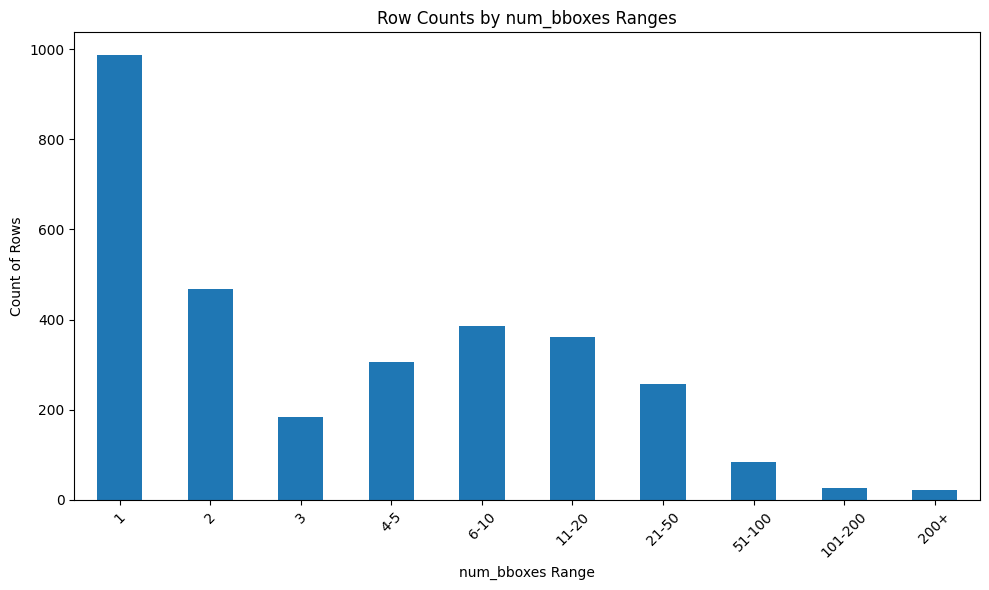

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Define bins and labels
bins = [0, 1, 2, 3, 5, 10, 20, 50, 100, 200, float("inf")]
labels = ["1", "2", "3", "4-5", "6-10", "11-20", "21-50", "51-100", "101-200", "200+"]

# Cut into bins
df["bbox_range"] = pd.cut(df["num_bboxes"], bins=bins, labels=labels, right=True)

# Count rows in each bin
counts = df["bbox_range"].value_counts().reindex(labels)

# Bar chart
plt.figure(figsize=(10,6))
counts.plot(kind="bar")

plt.title("Row Counts by num_bboxes Ranges")
plt.xlabel("num_bboxes Range")
plt.ylabel("Count of Rows")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
